# 00 · Supervised Learning, Data Splits and Cross-Validation

These notes set up the language used in every other notebook: what a supervised learning problem is, what "training" means, and how we measure whether a model will work on data it has never seen.

**Contents**

1. The supervised learning problem
2. Notation used in all the notes
3. Loss, risk and empirical risk
4. Overfitting, underfitting and the bias–variance trade-off
5. Train / validation / test split
6. $k$-fold cross-validation
7. Practical rules (leakage, stratification, time series)

## 1. The supervised learning problem

We observe pairs $(\mathbf{x}, y)$ drawn from an unknown distribution $P(\mathbf{x}, y)$:

- $\mathbf{x}$ are the **input variables** (features, predictors, covariates).
- $y$ is the **target** (label, response).

We want a function $h$ (the **hypothesis** or **model**) such that $h(\mathbf{x}) \approx y$ on **new** pairs from the same distribution.

It is *supervised* because the training data contains the correct answer $y$ for every $\mathbf{x}$. Two big families:

| Task | Target $y$ | Examples in these notes |
|---|---|---|
| **Regression** | real number, $y \in \mathbb{R}$ | Linear regression, regression trees |
| **Classification** | a class, $y \in \{0,1\}$ or $\{1,\dots,K\}$ | Logistic, softmax, SVM, classification trees |

A model family is chosen first (e.g. "all linear functions"), and it is described by **parameters** $\boldsymbol{\theta}$. *Learning* means choosing the $\boldsymbol{\theta}$ that makes the model good on the data. We write the model as $h_{\boldsymbol{\theta}}(\mathbf{x})$.

## 2. Notation used in all the notes

| Symbol | Meaning |
|---|---|
| $m$ | number of training examples |
| $n$ | number of input variables (features) |
| $\mathbf{x}^{(i)} \in \mathbb{R}^{n}$ | the $i$-th input vector; $x^{(i)}_j$ is its $j$-th feature |
| $y^{(i)}$ | the $i$-th target |
| $\boldsymbol{\theta}$ | parameter vector; $\theta_0$ is the intercept (bias) |
| $h_{\boldsymbol{\theta}}(\mathbf{x})$ | model prediction; also written $\hat{y}$ |
| $\mathbf{X} \in \mathbb{R}^{m \times (n+1)}$ | design matrix: one row per example, first column all ones |
| $\mathbf{y} \in \mathbb{R}^{m}$ | vector of all targets |
| $J(\boldsymbol{\theta})$ | loss (cost) function we minimise |
| $\alpha$ | learning rate of gradient descent |
| $\lambda$ | regularisation strength |

The trick of adding $x_0 = 1$ to every example lets us write the intercept inside the dot product:

$$
\boldsymbol{\theta}^\top \mathbf{x} = \theta_0 \cdot 1 + \theta_1 x_1 + \dots + \theta_n x_n ,
\qquad
\mathbf{X} =
\begin{bmatrix}
1 & x^{(1)}_1 & \cdots & x^{(1)}_n \\
1 & x^{(2)}_1 & \cdots & x^{(2)}_n \\
\vdots & \vdots & \ddots & \vdots \\
1 & x^{(m)}_1 & \cdots & x^{(m)}_n
\end{bmatrix}
$$

so that the vector of all predictions is simply $\mathbf{X}\boldsymbol{\theta}$.

## 3. Loss, risk and empirical risk

A **per-example loss** $\ell(\hat{y}, y)$ measures how bad one prediction is (e.g. squared error $(\hat{y}-y)^2$, or 1 if the class is wrong and 0 otherwise).

What we really care about is the **expected loss on new data**, the *risk*:

$$
R(\boldsymbol{\theta}) = \mathbb{E}_{(\mathbf{x},y)\sim P}\big[\ell(h_{\boldsymbol{\theta}}(\mathbf{x}), y)\big].
$$

We cannot compute it, because $P$ is unknown. What we can compute is the average loss on the training set, the **empirical risk**, which is what we call the loss function $J$:

$$
J(\boldsymbol{\theta}) = \frac{1}{m}\sum_{i=1}^{m} \ell\big(h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}), y^{(i)}\big).
$$

Training = minimising $J$. The whole problem of machine learning is that **a small $J$ on training data does not guarantee a small $R$ on new data**. The rest of this notebook is about how to detect and control that gap.

## 4. Underfitting, overfitting, bias and variance

- **Underfitting**: the model family is too simple to represent the pattern. Error is high on training *and* new data.
- **Overfitting**: the model is flexible enough to memorise the noise of the training set. Training error is low, error on new data is high.

The example below fits polynomials of increasing degree to 30 noisy points from a smooth curve.

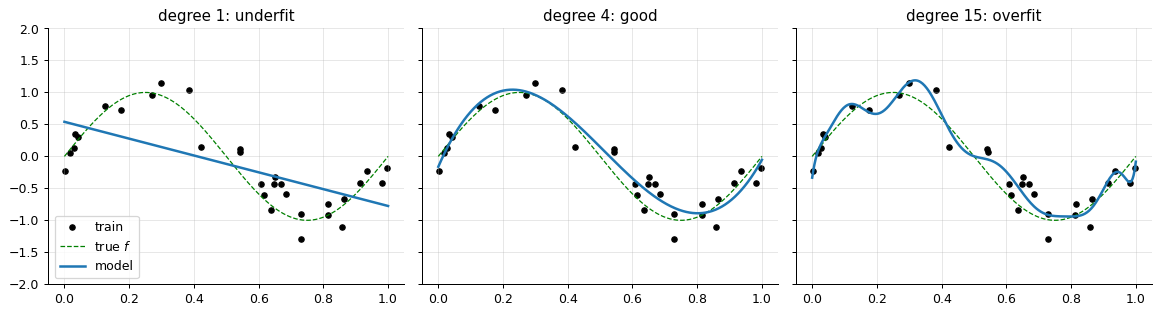

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

f_true = lambda x: np.sin(2 * np.pi * x)
x_tr = np.sort(rng.uniform(0, 1, 30)); y_tr = f_true(x_tr) + rng.normal(0, 0.25, 30)
x_te = np.sort(rng.uniform(0, 1, 200)); y_te = f_true(x_te) + rng.normal(0, 0.25, 200)

def poly_fit(x, y, d):
    Phi = np.vander(x, d + 1, increasing=True)
    return np.linalg.lstsq(Phi, y, rcond=None)[0]

def poly_pred(theta, x):
    return np.vander(x, len(theta), increasing=True) @ theta

grid = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, d, title in zip(axes, [1, 4, 15], ["degree 1: underfit", "degree 4: good", "degree 15: overfit"]):
    th = poly_fit(x_tr, y_tr, d)
    ax.scatter(x_tr, y_tr, s=18, color="k", label="train")
    ax.plot(grid, f_true(grid), "g--", lw=1, label="true $f$")
    ax.plot(grid, poly_pred(th, grid), "C0", lw=2, label="model")
    ax.set_ylim(-2, 2); ax.set_title(title)
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

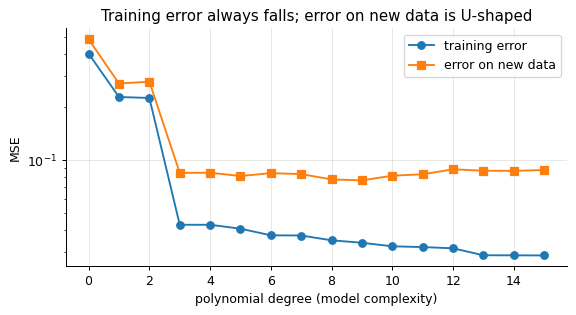

In [2]:
degrees = range(0, 16)
tr_err, te_err = [], []
for d in degrees:
    th = poly_fit(x_tr, y_tr, d)
    tr_err.append(np.mean((poly_pred(th, x_tr) - y_tr) ** 2))
    te_err.append(np.mean((poly_pred(th, x_te) - y_te) ** 2))

plt.figure(figsize=(6.5, 3.6))
plt.plot(degrees, tr_err, "o-", label="training error")
plt.plot(degrees, te_err, "s-", label="error on new data")
plt.yscale("log"); plt.xlabel("polynomial degree (model complexity)"); plt.ylabel("MSE")
plt.title("Training error always falls; error on new data is U-shaped")
plt.legend(); plt.tight_layout(); plt.show()

### Bias–variance decomposition (for squared error)

Assume $y = f(\mathbf{x}) + \varepsilon$ with $\mathbb{E}[\varepsilon]=0$, $\mathrm{Var}(\varepsilon)=\sigma^2$. Train the model on a random training set $\mathcal{D}$; call the fitted function $\hat f$ (it is random because $\mathcal{D}$ is). At a fixed point $\mathbf{x}$, write $\bar f = \mathbb{E}_{\mathcal{D}}[\hat f(\mathbf{x})]$.

**Claim.**
$$
\mathbb{E}\big[(y-\hat f(\mathbf{x}))^2\big] = \underbrace{\big(f(\mathbf{x})-\bar f\big)^2}_{\text{bias}^2} + \underbrace{\mathbb{E}\big[(\hat f(\mathbf{x})-\bar f)^2\big]}_{\text{variance}} + \underbrace{\sigma^2}_{\text{noise}}.
$$

**Proof.** Add and subtract $f$ and $\bar f$:
$$
y - \hat f = \underbrace{(y - f)}_{\varepsilon} + \underbrace{(f - \bar f)}_{\text{constant}} + \underbrace{(\bar f - \hat f)}_{\text{mean } 0}.
$$
Square and take expectations. The three cross terms vanish: $\varepsilon$ is independent of $\hat f$ and has mean 0; $(f-\bar f)$ is a constant multiplying $\mathbb{E}[\bar f - \hat f] = 0$. What is left is the sum of the three squared terms. $\blacksquare$

- Simple models: large bias, small variance (degree 1 above).
- Flexible models: small bias, large variance (degree 15 above).
- $\sigma^2$ cannot be removed by any model.

Every technique in these notes that "controls complexity" (regularisation, tree depth, $C$ in SVMs, averaging trees in a forest) is a way of moving along this trade-off.

## 5. Train / validation / test split

Because training error is optimistic, we must estimate performance on data **the model did not see**. The standard protocol splits the data once, at random, into three disjoint parts:

| Set | Typical size | Used for |
|---|---|---|
| **Training** | 60–80 % | fitting the parameters $\boldsymbol{\theta}$ (minimising $J$) |
| **Validation** | 10–20 % | choosing **hyperparameters** (degree, $\lambda$, tree depth, $C$, …) and comparing models |
| **Test** | 10–20 % | one final, unbiased estimate of performance. Touched **once**, at the end. |

**Parameters vs. hyperparameters.** Parameters ($\boldsymbol{\theta}$) are learned by minimising $J$ on the training set. Hyperparameters are choices made *before* training that $J$ cannot choose for you (minimising training error would always pick the most complex model, as the plot above shows). They are chosen by validation error.

**Why a separate test set?** If you pick the hyperparameter with the best validation score, that score is itself optimistically biased: you selected the winner of a contest on that very data. The test set is an independent referee.

In [3]:
from sklearn.model_selection import train_test_split

x_all = rng.uniform(0, 1, 150); y_all = f_true(x_all) + rng.normal(0, 0.25, 150)

# 60 / 20 / 20: first cut off the test set, then split the rest
x_rest, x_test, y_rest, y_test = train_test_split(x_all, y_all, test_size=0.20, random_state=0)
x_train, x_val, y_train, y_val = train_test_split(x_rest, y_rest, test_size=0.25, random_state=0)
print(f"train={len(x_train)}, val={len(x_val)}, test={len(x_test)}")

val_err = []
for d in degrees:
    th = poly_fit(x_train, y_train, d)
    val_err.append(np.mean((poly_pred(th, x_val) - y_val) ** 2))
best_d = int(np.argmin(val_err))

# refit on train+val with the chosen hyperparameter, report on test once
th = poly_fit(np.r_[x_train, x_val], np.r_[y_train, y_val], best_d)
print(f"best degree on validation = {best_d}")
print(f"test MSE (reported once)  = {np.mean((poly_pred(th, x_test) - y_test)**2):.3f}   (noise variance = {0.25**2:.3f})")

train=90, val=30, test=30
best degree on validation = 6
test MSE (reported once)  = 0.056   (noise variance = 0.062)


## 6. $k$-fold cross-validation

A single validation split is **noisy**: with few data, the score depends heavily on which points landed in the validation set. It also "wastes" data that could be used for training.

**$k$-fold cross-validation** (on the train+validation data; the test set stays aside):

1. Shuffle and split the data into $k$ folds of (almost) equal size $F_1,\dots,F_k$.
2. For $r = 1,\dots,k$: train on all folds except $F_r$, compute the error $E_r$ on $F_r$.
3. The CV estimate is the average $\;\mathrm{CV} = \frac{1}{k}\sum_{r=1}^k E_r$ (report also the standard deviation of the $E_r$).

Every example is used for validation exactly once and for training $k-1$ times.

- $k=5$ or $k=10$ are the usual choices.
- $k=m$ is **leave-one-out** (LOOCV): nearly unbiased but expensive and high-variance.
- Cost: $k$ trainings per hyperparameter value.

After choosing the hyperparameter by CV, **refit on all the non-test data**, then evaluate once on the test set.

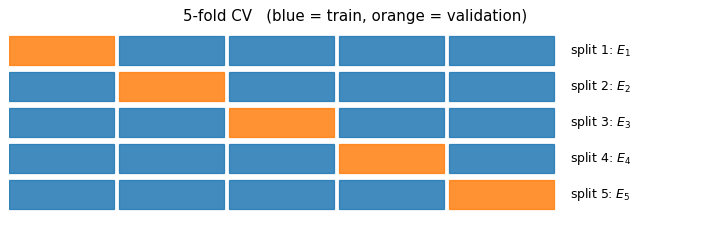

In [4]:
from matplotlib.patches import Rectangle
k = 5
fig, ax = plt.subplots(figsize=(8, 2.6))
for r in range(k):
    for f in range(k):
        ax.add_patch(Rectangle((f, k - 1 - r), 0.95, 0.8, color="C1" if f == r else "C0", alpha=0.85))
    ax.text(k + 0.1, k - 1 - r + 0.4, f"split {r+1}: $E_{r+1}$", va="center")
ax.set_xlim(0, k + 1.3); ax.set_ylim(-0.2, k); ax.axis("off")
ax.set_title("5-fold CV   (blue = train, orange = validation)")
plt.tight_layout(); plt.show()

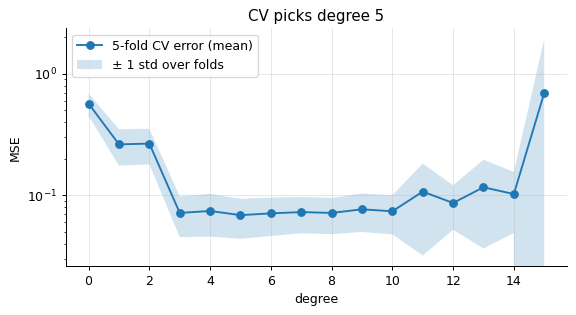

In [5]:
from sklearn.model_selection import KFold

X_rest = x_rest  # train + validation data (test still untouched)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_mean, cv_std = [], []
for d in degrees:
    errs = []
    for tr_idx, va_idx in kf.split(X_rest):
        th = poly_fit(X_rest[tr_idx], y_rest[tr_idx], d)
        errs.append(np.mean((poly_pred(th, X_rest[va_idx]) - y_rest[va_idx]) ** 2))
    cv_mean.append(np.mean(errs)); cv_std.append(np.std(errs))
cv_mean, cv_std = np.array(cv_mean), np.array(cv_std)

plt.figure(figsize=(6.5, 3.6))
plt.plot(degrees, cv_mean, "o-", label="5-fold CV error (mean)")
plt.fill_between(degrees, cv_mean - cv_std, cv_mean + cv_std, alpha=0.2, label="± 1 std over folds")
plt.yscale("log"); plt.xlabel("degree"); plt.ylabel("MSE"); plt.legend()
plt.title(f"CV picks degree {int(np.argmin(cv_mean))}")
plt.tight_layout(); plt.show()

## 7. Practical rules

1. **No information from validation/test may enter training.** This is called *data leakage*. The classic mistake: standardising features (computing mean and std) on the *whole* dataset before splitting. Compute $\mu, \sigma$ on the training fold only and apply them to the validation/test data. In scikit-learn, put preprocessing inside a `Pipeline` so it is refit on each CV fold.
2. **Stratify classification splits** (`stratify=y`, `StratifiedKFold`) so each fold has the same class proportions. Essential with imbalanced classes.
3. **Grouped data**: if several rows belong to the same entity (same customer, same patient, several photos of the same car), all rows of that entity must go in the same fold (`GroupKFold`). Otherwise the model is validated on near-copies of its training data.
4. **Time series**: never shuffle. Train on the past, validate on the future (`TimeSeriesSplit`, rolling or expanding window).
5. **The test set is used once.** If you go back and change the model after looking at the test score, it has become a validation set.

**Summary**

- Learning = minimising the empirical loss $J(\boldsymbol{\theta})$ over the training set.
- What matters is error on new data; training error underestimates it.
- Parameters are fit on training data; hyperparameters are chosen on validation data or by $k$-fold CV; the test set gives the final number.